# Imports

In [1]:
import os
import sys

In [2]:
current_dir =  os.getcwd()
# replace this following line in the path your frank2d files are.
parent_dir = os.path.abspath(os.path.join(current_dir, os.pardir))
sys.path.append(parent_dir)

In [3]:
parent_dir

'/localhome/home/zgdz996/frank2d'

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import time

In [5]:
# frank2d
from frank2d import Frank2D
from frank2d.geometry import Geometry
from frank2d.plot import Plot
from frank2d.posterior_optimization import *
from frank2d.constants import rad_to_arcsec, deg_to_rad
from frank2d.posterior_optimization import MAPEstimator

In [6]:

dir = "./../../data/"
data_file = dir + "uvtable_nonsym_disc_blob_noisy.npz"
inc = 0
pa = 0
dra = 0
ddec = 0
rout = 1*2

# Load data
file = np.load(data_file)
u, v, Vis, Weights = file['u'], file['v'], file['vis'], file['weights']
uvtable = {'u': u, 'v': v, 'vis': Vis, 'weights': Weights }

geom = Geometry(inc, pa, dra, ddec)

## Run frank2d for differents N

In [7]:
N = [50, 100, 300, 500, 1000, 3000, 4000, 6000]

In [8]:
frank2d_objects = []

In [9]:
times = []

In [10]:
params_N80 = {'m': -4.572459366888535, 'c': 1.0086866109221515e+24, 'l': 68720.91547274287}

In [12]:
for i in range(len(N)):
    start = time.time()
    frank2d = Frank2D(N[i], rout)
    frank2d.fit(data = uvtable, kernel_params = params_N80, rtol = 1e-8)

    end = time.time()
    total_time = end - start
    times.append(total_time)
    print(f"xxxxxxxxxxxxxxxxxxxxxxxxx F2D withN={N[i]} took {end - start} seconds xxxxxxxxxxxxxxxxxxxxxxxxxxxx")
    frank2d_objects.append(frank2d)


===>  Setting gridded data...
===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -4.572459366888535, 'c': 1.0086866109221515e+24, 'l': 68720.91547274287}
===>  Creating sparse linear system...
        +  Kernel = 0.00  min |  0.14 seconds
        +  Building system = 0.00  min |  0.14 seconds
===>  Solving linear system...
      .... iteration  0 :   actual tol  1.22e+08  versus  1.22e+00
      .... iteration  10 :   actual tol  5.15e+06  versus  1.22e+00
      .... iteration  20 :   actual tol  3.35e+06  versus  1.22e+00
      .... iteration  30 :   actual tol  1.39e+06  versus  1.22e+00
      .... iteration  40 :   actual tol  3.60e+05  versus  1.22e+00
      .... iteration  50 :   actual tol  1.59e+05  versus  1.22e+00
      .... iteration  60 :   actual tol  4.32e+04  versus  1.22e+00
      .... iteration  70 :   actual tol  8.69e+04  versus  1.22e+00
      .... iteration  80 :   actual tol  1.84e+04  versus  1.22e+00
      .... iteration  90 :   actual tol  1.66e+

### Complexity plot 

Text(0.5, 1.0, 'Frank2D for a NxN pixels image')

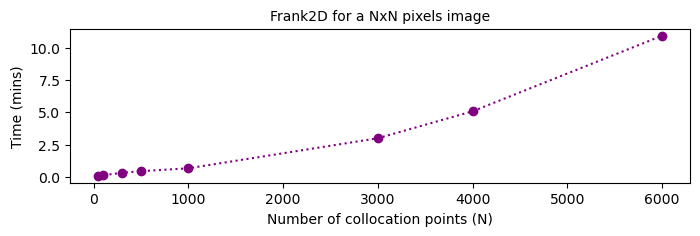

In [15]:
plt.figure(figsize=(8,2))
plt.plot(N, np.array(times)/60, marker='o', ls=':', color = 'purple')
#plt.xscale('log')
#plt.yscale('log')
plt.xlabel('Number of collocation points (N)', fontsize=10)
plt.ylabel('Time (mins)', fontsize=10)
plt.title(f'Frank2D for a NxN pixels image', fontsize=10)

## Analize differents results

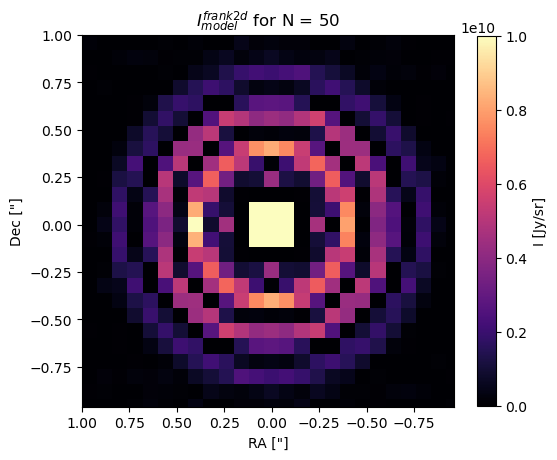

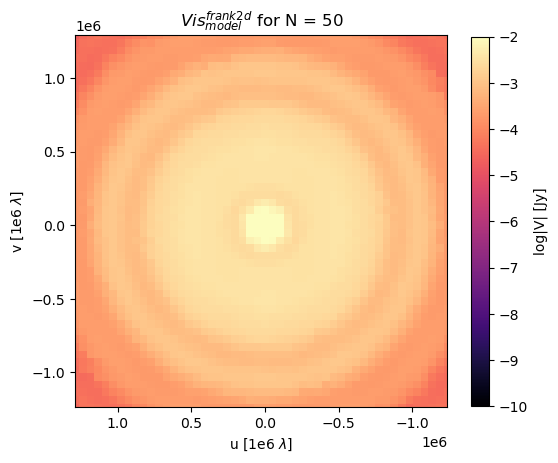

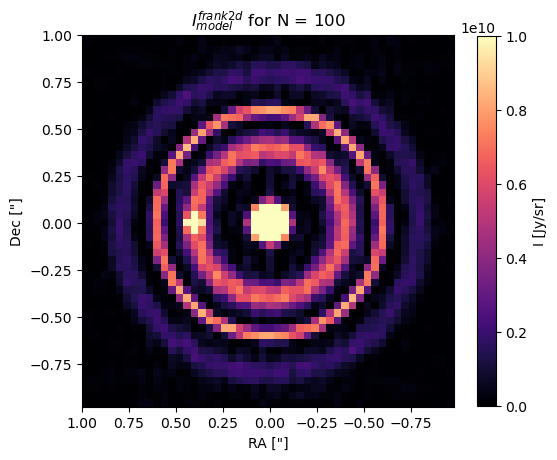

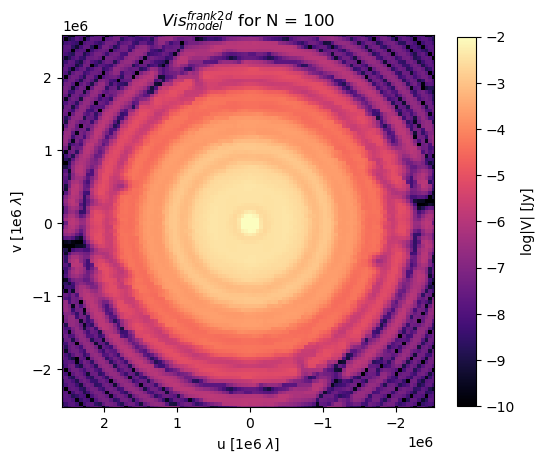

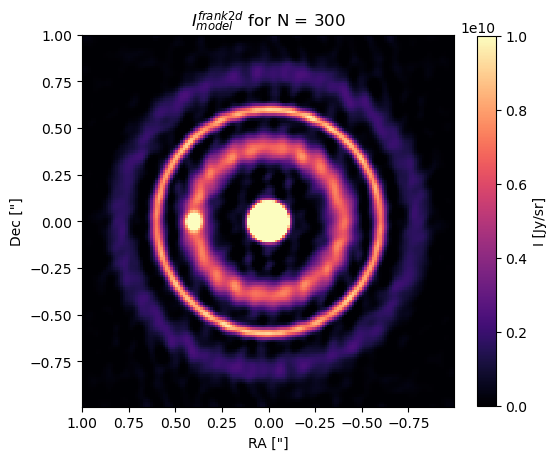

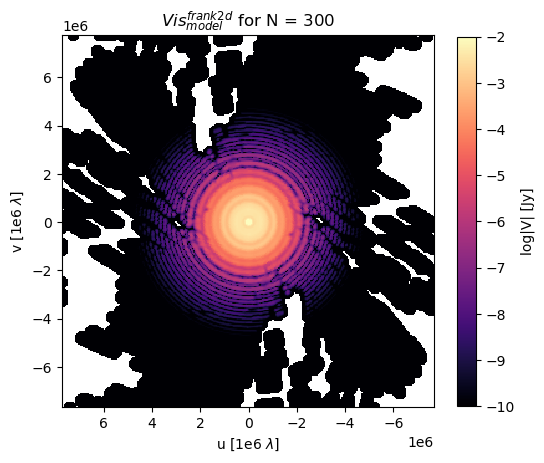

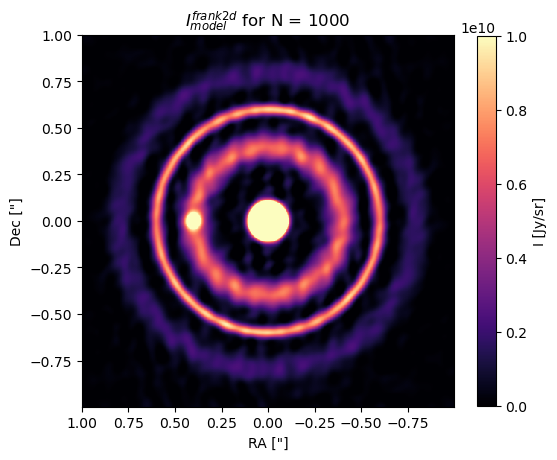

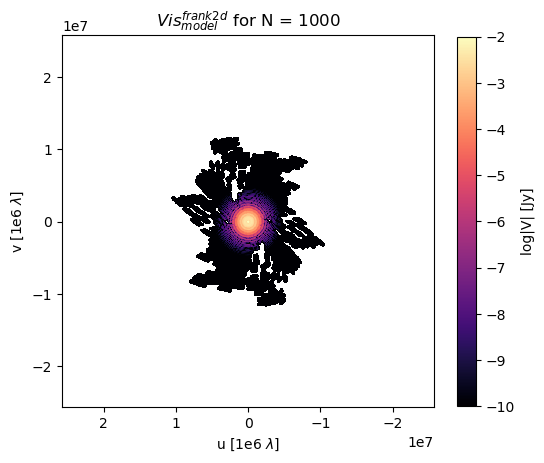

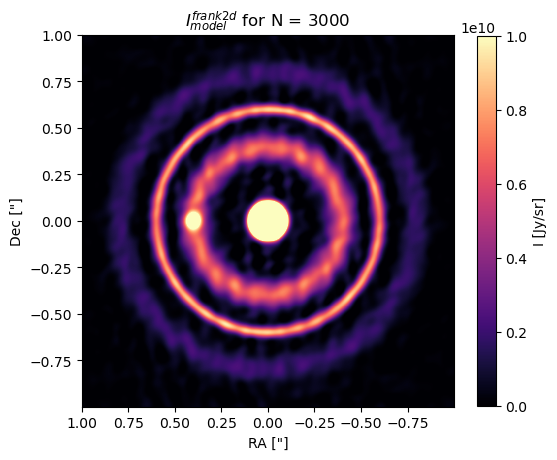

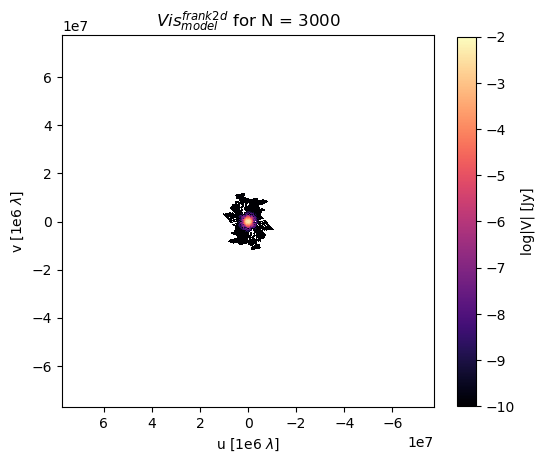

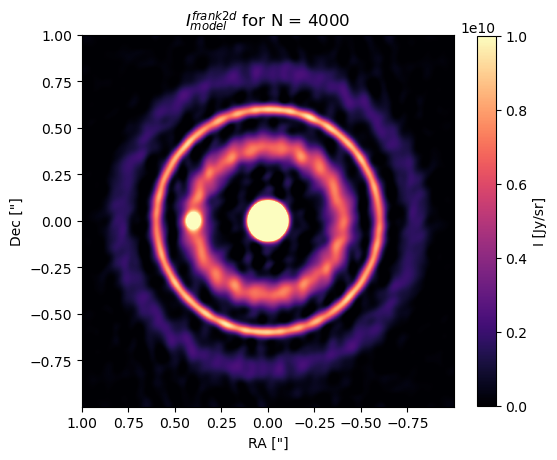

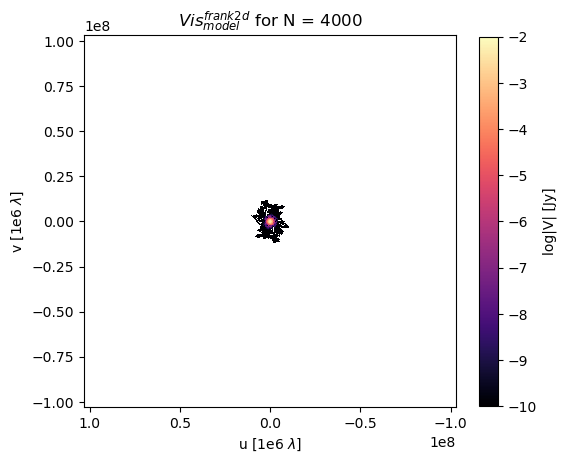

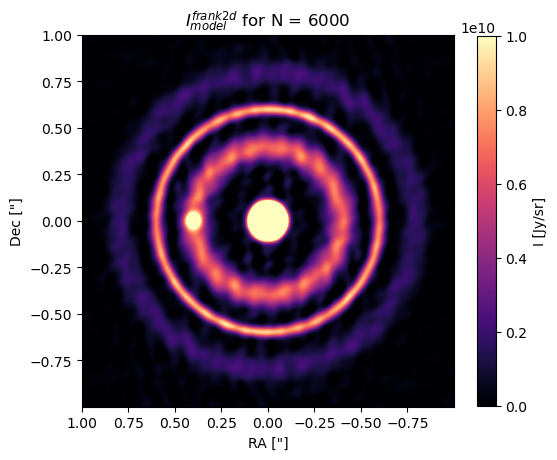

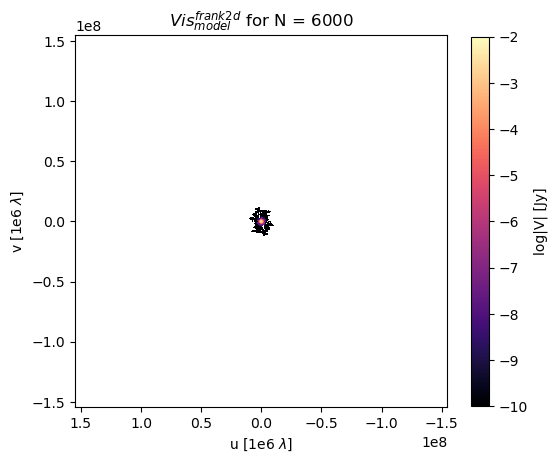

In [ ]:
for i in range(len(N)):
    Plot_ = Plot(frank2d_objects[i])
    Plot_.intensity( vmax=1e10,  gamma = 1, zoom=2,
                     title= r'$I_{model}^{frank2d}$ for N = ' + str(N[i]))
    Plot_.visibility(fig_size = 6,
                     title = r'$Vis_{model}^{frank2d}$ for N = ' + str(N[i]))